# e26 Norway Transferability by Number of Pairs (vary #sources, fixed #targets)

Analysis of experiment `e25TR_norway_hybrid_sampling`, which trains TAGConv (30 epochs) and SparseGT (1 epoch)
on **hybrid-sampled** datasets for resolution 4.

Hybrid sampling uses a mix of uniform and biased source/target selection:
- **Sources**: 50% uniform, 50% biased toward high elevation gradient
- **Targets**: 50% uniform, 50% biased toward proximity to the source

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from pathlib import Path
import wandb
import wandb_buddy as wb
from tqdm import tqdm

In [76]:
ENTITY = "alelab"
PROJECT = "terrains"
TAG = "e26TR_norway_transferability_num_pairs"
ERROR_COL = "test_mae"
ERROR_LABEL = "Test MAE"
ORIGINAL_DIM = 2000

## Helper functions

In [77]:
def extract_resolution(row):
    dataset_name = str(row["dataset_name"])
    res_match = re.search(r"res(\d+)", dataset_name)
    return int(res_match.group(1))


def get_metric_history_mean(entity, project, run_id, metric):
    api = wandb.Api()
    run = api.run(f"{entity}/{project}/{run_id}")
    history = run.history(keys=[metric], pandas=True)
    if history.empty or metric not in history.columns:
        return np.nan
    values = history[metric].dropna()
    return values.mean() if len(values) > 0 else np.nan


def add_metric_from_history(df, entity, project, source_metric, target_col):
    means = []
    for run_id in tqdm(df["id"], desc=f"Fetching {source_metric}"):
        means.append(get_metric_history_mean(entity, project, run_id, source_metric))
    df[target_col] = means
    return df

---
## Load runs

In [78]:
print(f"Fetching runs with tag: {TAG}")
df = wb.load_runs(ENTITY, PROJECT, tags=[TAG])
print(f"Found {len(df)} runs")

Fetching runs with tag: e26TR_norway_transferability_num_pairs
Found 42 runs


In [79]:
print("Available columns:", df.columns.tolist())

# layer_type may be logged under a different name
if "layer_type" not in df.columns:
    # Try to infer from the run name (e.g. "terrain-graph-TAGConv-...")
    df["layer_type"] = df["name"].str.extract(r"(TAGConv|SparseGT)", expand=False)
    print(f"Inferred layer_type from run name: {df['layer_type'].value_counts().to_dict()}")

df = add_metric_from_history(df, ENTITY, PROJECT, "test_batch_mae", "test_mae")

print(f"\nRuns with valid test_mae: {df['test_mae'].notna().sum()} / {len(df)}")
print(f"\nBy layer_type:")
print(df.groupby("layer_type")["test_mae"].apply(lambda x: f"{x.notna().sum()}/{len(x)} valid"))

Available columns: ['name', 'id', 'state', 'created_at', 'heartbeat_at', 'tags', 'sweep_id', '_runtime', '_step', '_timestamp', '_wandb', 'epoch', 'global_step', 'test_batch_loss', 'test_batch_mae', 'test_batch_mse', 'test_batch_nmae', 'train_loss', 'train_mae', 'train_mse', 'train_nmae', 'val_loss', 'val_mae', 'val_mse', 'val_nmae']
Inferred layer_type from run name: {'TAGConv': 21, 'SparseGT': 21}


Fetching test_batch_mae: 100%|██████████| 42/42 [00:38<00:00,  1.09it/s]


Runs with valid test_mae: 42 / 42

By layer_type:
layer_type
SparseGT    21/21 valid
TAGConv     21/21 valid
Name: test_mae, dtype: object


---
## Best performance per number of sources

In [80]:
df["num_sources"] = df["name"].str.extract(r"(\d+)_sources").astype(float)
df["num_pairs"] = df["num_sources"] * 100

df_valid = df.dropna(subset=[ERROR_COL, "num_sources"])
best_per_sources = df_valid.loc[
    df_valid.groupby(["layer_type", "num_sources"])[ERROR_COL].idxmin()
]
print(f"Best runs per num_sources: {len(best_per_sources)}")

Best runs per num_sources: 40


In [81]:
cols = ["name", "layer_type", "num_sources", "num_pairs", "test_mae", "epochs", "state"]
display_cols = [c for c in cols if c in best_per_sources.columns]
best_per_sources.sort_values(["layer_type", "num_sources"])[display_cols]

,name,layer_type,num_sources,num_pairs,test_mae,state
21,terrain-graph-SparseGT-res04_5_sources-stage1,SparseGT,5.0,500.0,0.774908,finished
23,terrain-graph-SparseGT-res04_10_sources-stage1,SparseGT,10.0,1000.0,0.758922,finished
25,terrain-graph-SparseGT-res04_15_sources-stage1,SparseGT,15.0,1500.0,0.759117,finished
27,terrain-graph-SparseGT-res04_20_sources-stage1,SparseGT,20.0,2000.0,0.740397,finished
29,terrain-graph-SparseGT-res04_25_sources-stage1,SparseGT,25.0,2500.0,0.761768,finished
31,terrain-graph-SparseGT-res04_30_sources-stage1,SparseGT,30.0,3000.0,0.761847,finished
33,terrain-graph-SparseGT-res04_35_sources-stage1,SparseGT,35.0,3500.0,0.750155,finished
35,terrain-graph-SparseGT-res04_40_sources-stage1,SparseGT,40.0,4000.0,0.759095,finished
37,terrain-graph-SparseGT-res04_45_sources-stage1,SparseGT,45.0,4500.0,0.765097,finished
39,terrain-graph-SparseGT-res04_50_sources-stage1,SparseGT,50.0,5000.0,0.747881,finished


---
## Transferability plot

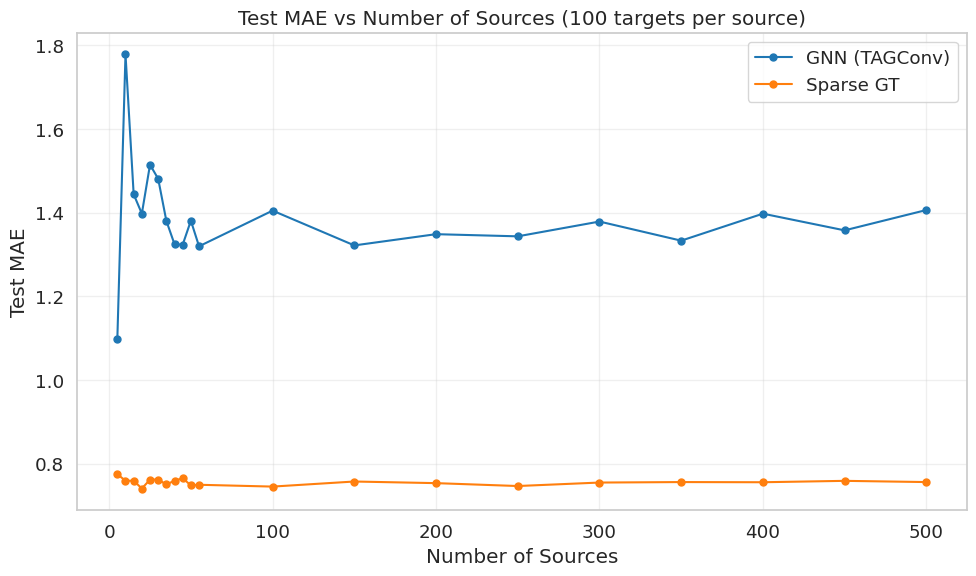

In [82]:
sns.set_theme(style="whitegrid", font_scale=1.2)

LABEL_MAP = {"TAGConv": "GNN (TAGConv)", "SparseGT": "Sparse GT"}
COLOR_MAP = {"GNN (TAGConv)": "#1f77b4", "Sparse GT": "#ff7f0e"}

fig, ax = plt.subplots(figsize=(10, 6))

for layer in ["TAGConv", "SparseGT"]:
    label = LABEL_MAP[layer]
    data = best_per_sources[
        best_per_sources["layer_type"] == layer
    ].sort_values("num_sources")

    if data.empty:
        continue

    ax.plot(
        data["num_sources"], data[ERROR_COL],
        marker="o", label=label, color=COLOR_MAP[label],
        linewidth=1.5, markersize=5,
    )

ax.set_xlabel("Number of Sources")
ax.set_ylabel(ERROR_LABEL)
ax.set_title("Test MAE vs Number of Sources (100 targets per source)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Training curves (loss over epochs)

Fetching loss curves: 100%|██████████| 6/6 [00:03<00:00,  1.62it/s]


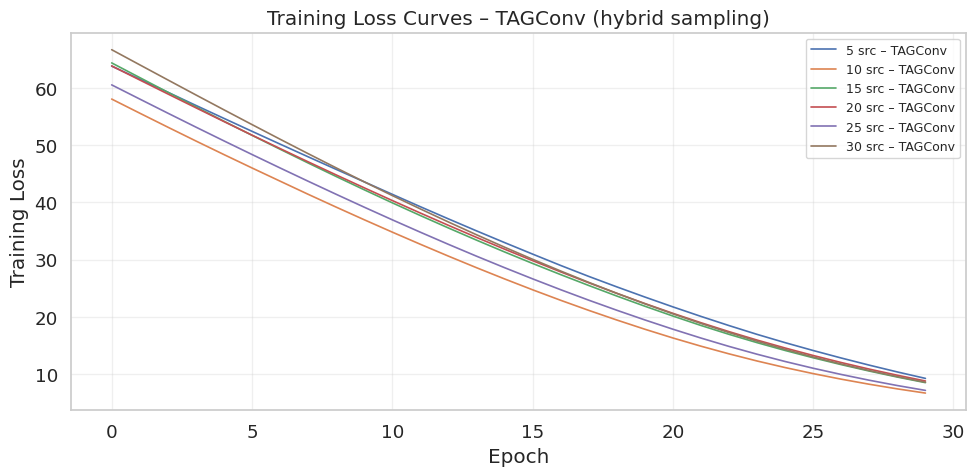

In [83]:
def fetch_loss_curves(df, entity, project, metric="train_loss", max_runs=6):
    api = wandb.Api()
    curves = {}
    subset = df.head(max_runs)
    for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Fetching loss curves"):
        run = api.run(f"{entity}/{project}/{row['id']}")
        history = run.history(keys=[metric, "epoch"], pandas=True)
        if not history.empty and metric in history.columns:
            label = f"{int(row['num_sources'])} src – {row['layer_type']}"
            curves[label] = history[["epoch", metric]].dropna()
    return curves

tagconv_runs = df[
    (df["layer_type"] == "TAGConv") & df["test_mae"].notna()
].sort_values("num_sources")

curves = fetch_loss_curves(tagconv_runs, ENTITY, PROJECT, metric="train_loss", max_runs=6)

if curves:
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, hist in curves.items():
        ax.plot(hist["epoch"], hist["train_loss"], label=label, linewidth=1.2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.set_title("Training Loss Curves – TAGConv (hybrid sampling)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No training loss curves available.")

---
## Error distribution by number of sources

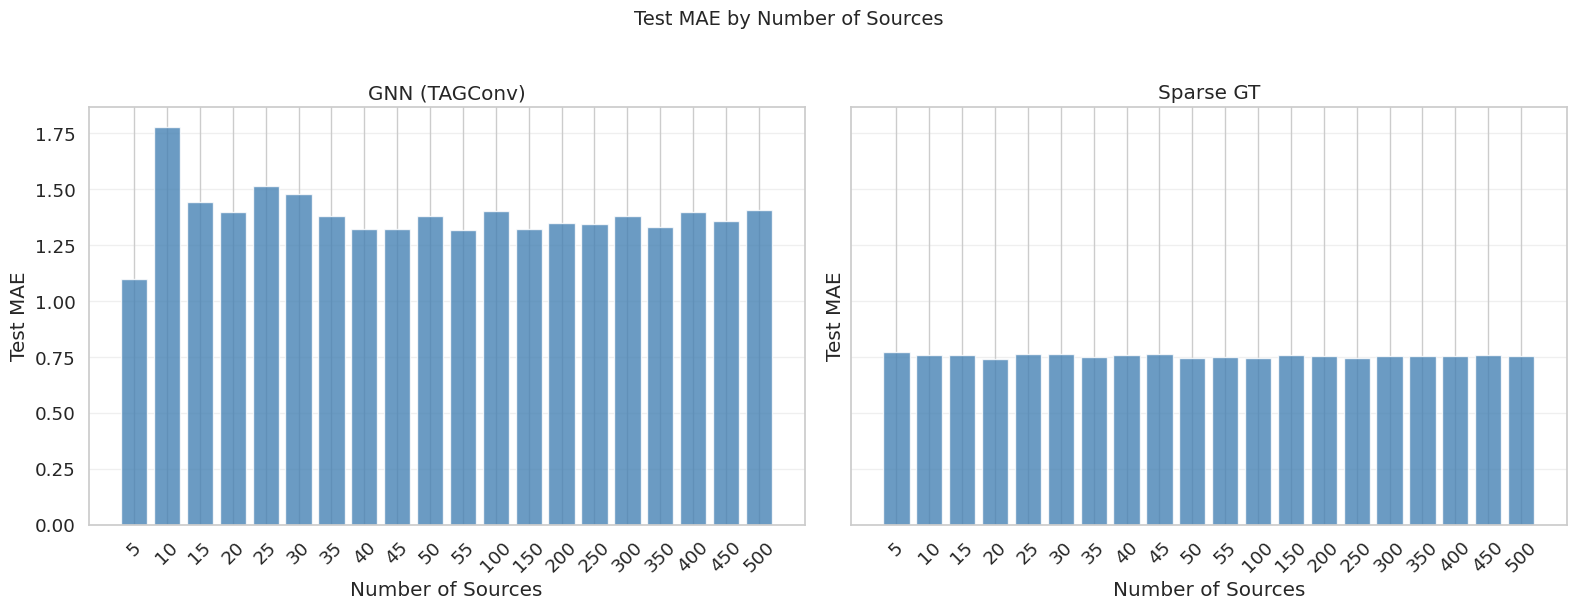

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, layer in zip(axes, ["TAGConv", "SparseGT"]):
    label = LABEL_MAP[layer]
    sub = best_per_sources[
        best_per_sources["layer_type"] == layer
    ].sort_values("num_sources")

    if sub.empty:
        ax.set_title(f"{label}: no data")
        continue

    ax.bar(sub["num_sources"].astype(int).astype(str), sub["test_mae"], color="steelblue", alpha=0.8)
    ax.set_xlabel("Number of Sources")
    ax.set_ylabel(ERROR_LABEL)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Test MAE by Number of Sources", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Run status summary

In [85]:
print("=== e26 Transferability by Num Pairs – Run Summary ===")
print(f"Total runs: {len(df)}")
print(f"\nBy state:")
print(df["state"].value_counts().to_string())
print(f"\nBy layer_type:")
print(df["layer_type"].value_counts().to_string())
expected_sources = list(range(50, 1050, 50))
print(f"\nNum sources covered: {sorted(df['num_sources'].dropna().astype(int).unique())}")
print(f"Expected num_sources (50–1000, step 50): {expected_sources}")
missing = set(expected_sources) - set(df["num_sources"].dropna().astype(int))
if missing:
    print(f"Missing: {sorted(missing)}")
else:
    print("All source counts present.")

=== e26 Transferability by Num Pairs – Run Summary ===
Total runs: 42

By state:
state
finished    42

By layer_type:
layer_type
TAGConv     21
SparseGT    21

Num sources covered: [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(100), np.int64(150), np.int64(200), np.int64(250), np.int64(300), np.int64(350), np.int64(400), np.int64(450), np.int64(500)]
Expected num_sources (50–1000, step 50): [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]
Missing: [550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]
